# Stationarity diagnostics for the METEORv1.6 noise model

This notebook produces the supplemental diagnostic figures that address reviewer concerns about the stationarity assumptions embedded in the METEOR-NOISE PCA basis and the VARX coefficient matrices. Two tests are run on the NorESM2-MM historical+SSP2-4.5 training record (default emulator training data):

1. **PCA split-sample.** The noise model is refit separately on the early half (1850--1974) and the late half (1976--2100). The leading EOFs are compared by spatial pattern correlation to test whether the same fixed basis is defensible across climate states.
2. **VARX rolling coefficients.** The noise model is fit on a sequence of overlapping 100-year windows sliding by 25 years. The spectral radius of the companion matrix, Frobenius norms of $A_1, A_2, B$, and a small panel of leading self-lag coefficients are recorded per window.

Outputs written to `../paper/paper_figures/`:
- `suppfig_stationarity_tas.pdf`
- `suppfig_stationarity_pr.pdf`

Numerical summaries are printed inline for the response letter.

Runtime: ~30-40 minutes total on a laptop (PCA fits ~5 min per variable, VARX rolling ~7-10 min per variable).

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path
import warnings

REPO_ROOT = Path().resolve().parents[1]  # METEOR repo root
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display

warnings.filterwarnings('ignore')

from meteor.noise_generator import MeteorNoiseGenerator

CACHE = REPO_ROOT / 'cache' / 'cmip6'
FIGURE_DIR = os.environ.get('METEOR_PAPER_FIGURES', '../paper/paper_figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

MODEL = 'NorESM2-MM'
SCENARIO = 'ssp245'
N_MODES = 40
LAG = 2

# PCA split boundaries in the concatenated 251-year composite (months from Jan 1850).
# Early = 1850-01 through 1974-12 (125 yr).  Late = 1976-01 through 2100-12 (125 yr).
EARLY_SLICE = slice(0, 1500)
LATE_SLICE  = slice(1512, 3012)
N_COMPARE = 10

# VARX rolling parameters.
WINDOW_YEARS = 100
STEP_YEARS = 25
BASE_YEAR = 1850
TOTAL_MONTHS = 3012

def save_and_show(fig, name):
    '''Save fig as PDF + PNG, display inline, then close.'''
    pdf = os.path.join(FIGURE_DIR, f'{name}.pdf')
    png = os.path.join(FIGURE_DIR, f'{name}.png')
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, bbox_inches='tight', dpi=150)
    print(f'saved: {pdf}')
    print(f'saved: {png}')
    display(fig)
    plt.close(fig)

print(f'REPO_ROOT = {REPO_ROOT}')
print(f'FIGURE_DIR = {FIGURE_DIR}')
print(f'CACHE = {CACHE}')

REPO_ROOT = /Users/bensan/GitHub/METEOR
FIGURE_DIR = ../paper/paper_figures
CACHE = /Users/bensan/GitHub/METEOR/cache/cmip6


In [2]:
import pickle

CACHE_LOCAL = Path('./stationarity_cache')
CACHE_LOCAL.mkdir(exist_ok=True)

def cached(name):
    def deco(fn):
        def wrap(*args, **kwargs):
            path = CACHE_LOCAL / f'{name}.pkl'
            if path.exists():
                print(f'loading cached {name}')
                with open(path, 'rb') as f:
                    return pickle.load(f)
            out = fn(*args, **kwargs)
            with open(path, 'wb') as f:
                pickle.dump(out, f)
            print(f'wrote cache: {path}')
            return out
        return wrap
    return deco

def load_composite(variable):
    '''Concatenate historical + ssp245 monthly cached files and reindex month.'''
    hist = xr.open_dataset(CACHE / f'{MODEL}_historical_{variable}_monthly.nc')
    ssp  = xr.open_dataset(CACHE / f'{MODEL}_{SCENARIO}_{variable}_monthly.nc')
    start = int(hist['month'].values[-1]) + 1
    ssp = ssp.assign_coords(month=np.arange(start, start + ssp.sizes['month']))
    return xr.concat([hist, ssp], dim='month')

def picontrol_baseline(variable):
    ds = xr.open_dataset(CACHE / f'{MODEL}_piControl_{variable}_yearly.nc')
    return float(ds[variable].mean().values)

def fit_subset(data, variable, month_slice, baseline, use_exog='none'):
    subset = data.sel(month=month_slice)
    gen = MeteorNoiseGenerator(n_modes=N_MODES, lag_order=LAG, use_exog=use_exog)
    gen.fit(subset, variable, picontrol_baseline=baseline)
    return gen

## 2. PCA split-sample diagnostic

Refit the noise model on the early and late halves of the training record, then compare leading EOFs by absolute spatial pattern correlation. Best-match indices allow for mode reordering between the two fits (i.e., early EOF $i$ paired with the late EOF that has the largest $|r|$ against it).

In [3]:
def pattern_correlations(early_gen, late_gen, n=N_COMPARE):
    A = early_gen.pca.components_[:n]
    B = late_gen.pca.components_[:n]
    A = A - A.mean(axis=1, keepdims=True)
    B = B - B.mean(axis=1, keepdims=True)
    A /= np.linalg.norm(A, axis=1, keepdims=True)
    B /= np.linalg.norm(B, axis=1, keepdims=True)
    return np.abs(A @ B.T)

def best_match_summary(corr):
    idx = corr.argmax(axis=1)
    return idx, corr[np.arange(len(idx)), idx]

def run_pca_split(variable):
    @cached(f'pca_split_{variable}')
    def _run():
        print(f'--- PCA split-sample: {variable} ---')
        data = load_composite(variable)
        baseline = picontrol_baseline(variable)
        print(f'  months: {data.sizes["month"]}, piControl baseline: {baseline:.3f}')
        print('  fitting early half...')
        early = fit_subset(data, variable, EARLY_SLICE, baseline)
        print('  fitting late half...')
        late = fit_subset(data, variable, LATE_SLICE, baseline)
        corr = pattern_correlations(early, late)
        idx, best = best_match_summary(corr)
        diag = np.diag(corr)
        print(f'  top-{N_COMPARE} best-match |r|: mean={best.mean():.3f}  median={np.median(best):.3f}')
        print(f'  same-index |r|:            mean={diag.mean():.3f}  median={np.median(diag):.3f}')
        for i in range(N_COMPARE):
            print(f'    EOF {i+1:2d} -> late {idx[i]+1:2d}: |r| = {best[i]:.3f}')
        return dict(early=early, late=late, corr=corr, idx=idx, best=best, diag=diag)
    return _run()

In [4]:
pca_tas = run_pca_split('tas')

loading cached pca_split_tas


In [5]:
pca_pr = run_pca_split('pr')

loading cached pca_split_pr


## 3. VARX rolling-window diagnostic

Fit the noise model on overlapping 100-year windows sliding through the training record by 25 years. For each window we record:

- **Spectral radius** of the companion matrix -- the VAR stability margin (values below 1 indicate stationarity).
- **Frobenius norms** of $A_1, A_2$ (autoregressive) and $B$ (exogenous) matrices.
- **Individual leading self-lag coefficients** $A_1[i,i]$ for $i \in \{0,1,2\}$ and their diagonal mean.

$B$ magnitudes should be interpreted with caution: the exogenous input is smoothed global temperature, whose variance differs markedly between early (near-stationary) and late (strongly trending) windows, so raw $B$ Frobenius norm partly reflects this scaling rather than genuine coefficient drift.

In [6]:
def window_starts_months():
    win_mo = WINDOW_YEARS * 12
    step_mo = STEP_YEARS * 12
    return list(range(0, TOTAL_MONTHS - win_mo + 1, step_mo))

def var_diagnostics(gen):
    res = gen.varx_results
    coefs = res.coefs  # (lag_order, n, n)
    A1, A2 = coefs[0], coefs[1]
    n = A1.shape[0]
    companion = np.zeros((2*n, 2*n))
    companion[:n, :n] = A1
    companion[:n, n:] = A2
    companion[n:, :n] = np.eye(n)
    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(companion))))
    B = getattr(res, 'coefs_exog', None)
    B_frob = float(np.linalg.norm(B)) if B is not None else float('nan')
    return dict(
        spectral_radius=spectral_radius,
        A1_frob=float(np.linalg.norm(A1)),
        A2_frob=float(np.linalg.norm(A2)),
        A1_diag_mean=float(np.mean(np.diag(A1))),
        B_frob=B_frob,
        A1_00=float(A1[0, 0]),
        A1_11=float(A1[1, 1]),
        A1_22=float(A1[2, 2]),
    )

def run_varx_rolling(variable):
    @cached(f'varx_rolling_{variable}')
    def _run():
        print(f'--- VARX rolling: {variable} ---')
        data = load_composite(variable)
        baseline = picontrol_baseline(variable)
        starts = window_starts_months()
        centers = [BASE_YEAR + (s + WINDOW_YEARS*12//2) // 12 for s in starts]
        print(f'  {len(starts)} windows, centers: {centers}')
        records = []
        for start, center in zip(starts, centers):
            subset = data.sel(month=slice(start, start + WINDOW_YEARS*12 - 1))
            gen = MeteorNoiseGenerator(n_modes=N_MODES, lag_order=LAG, use_exog='temp_only')
            gen.fit(subset, variable, picontrol_baseline=baseline)
            rec = var_diagnostics(gen)
            rec['window_center_year'] = center
            records.append(rec)
            print(f'  center {center}: spec_radius={rec["spectral_radius"]:.3f}  '
                  f'A1={rec["A1_frob"]:.3f}  A2={rec["A2_frob"]:.3f}  '
                  f'A1_diag_mean={rec["A1_diag_mean"]:.3f}')
        return dict(centers=centers, records=records)
    return _run()

In [7]:
varx_tas = run_varx_rolling('tas')

loading cached varx_rolling_tas


In [8]:
varx_pr = run_varx_rolling('pr')

loading cached varx_rolling_pr


## 4. Combined supplemental figures

One figure per variable with both diagnostics:
- Top row: PCA correlation heatmap + top-3 EOF pair maps (early vs late, sign-aligned for display).
- Bottom row: VARX spectral radius, Frobenius norms of $A_1$ and $A_2$, and the diagonal mean of $A_1$.

In [9]:
def render_combined(variable, pca_res, varx_res, name):
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(4, 6, figure=fig, hspace=0.55, wspace=0.5,
                  left=0.06, right=0.98, top=0.92, bottom=0.06)

    # (a) PCA correlation heatmap
    ax_hm = fig.add_subplot(gs[0:2, 0:2])
    im = ax_hm.imshow(pca_res['corr'], vmin=0, vmax=1, cmap='viridis', origin='lower')
    ax_hm.set_title('(a) |corr| between\nearly / late EOFs')
    ax_hm.set_xlabel('late EOF index')
    ax_hm.set_ylabel('early EOF index')
    ax_hm.set_xticks(range(0, pca_res['corr'].shape[1], 2))
    ax_hm.set_yticks(range(0, pca_res['corr'].shape[0], 2))
    fig.colorbar(im, ax=ax_hm, fraction=0.046)

    # (b) Top-3 EOF pair maps in a 3x2 inner grid on the top-right
    early = pca_res['early']
    late = pca_res['late']
    lat = early.coords['lat']
    lon = early.coords['lon']
    nlat, nlon = len(lat), len(lon)
    inner = fig.add_gridspec(3, 2, left=0.42, right=0.98, top=0.88, bottom=0.55,
                             hspace=0.35, wspace=0.1)
    for k in range(3):
        e = early.pca.components_[k].reshape(nlat, nlon)
        j = pca_res['idx'][k]
        L = late.pca.components_[j].reshape(nlat, nlon)
        if np.corrcoef(e.ravel(), L.ravel())[0, 1] < 0:
            L = -L
        vmax = max(np.abs(e).max(), np.abs(L).max())
        ax_e = fig.add_subplot(inner[k, 0])
        ax_l = fig.add_subplot(inner[k, 1])
        ax_e.imshow(e, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
        ax_l.imshow(L, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
        ax_e.set_title(f'early EOF {k+1}', fontsize=9)
        ax_l.set_title(f'late EOF {j+1}  |r|={pca_res["corr"][k, j]:.2f}', fontsize=9)
        for ax in (ax_e, ax_l):
            ax.set_xticks([])
            ax.set_yticks([])
    fig.text(0.70, 0.90, '(b) leading EOF pairs (early | late, sign-aligned)',
             ha='center', fontsize=11)

    # (c) VARX spectral radius
    centers = varx_res['centers']
    recs = varx_res['records']
    ax_sr = fig.add_subplot(gs[2, 0:2])
    ax_sr.plot(centers, [r['spectral_radius'] for r in recs], 'o-', color='C0')
    ax_sr.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
    ax_sr.set_ylabel('spectral radius')
    ax_sr.set_title('(c) VARX companion spectral radius')
    ax_sr.set_ylim(0.85, 1.02)
    ax_sr.set_xlabel('window center year')

    # (d) A1 / A2 Frobenius norms
    ax_fr = fig.add_subplot(gs[2, 2:4])
    ax_fr.plot(centers, [r['A1_frob'] for r in recs], 'o-', label='$||A_1||_F$')
    ax_fr.plot(centers, [r['A2_frob'] for r in recs], 's-', label='$||A_2||_F$')
    ax_fr.set_title('(d) autoregressive coefficient norms')
    ax_fr.set_xlabel('window center year')
    ax_fr.legend()

    # (e) leading self-lag coefficients
    ax_dl = fig.add_subplot(gs[2, 4:6])
    ax_dl.plot(centers, [r['A1_00'] for r in recs], 'o-', label='$A_1[0,0]$ (mode 1)')
    ax_dl.plot(centers, [r['A1_11'] for r in recs], 's-', label='$A_1[1,1]$ (mode 2)')
    ax_dl.plot(centers, [r['A1_22'] for r in recs], '^-', label='$A_1[2,2]$ (mode 3)')
    ax_dl.plot(centers, [r['A1_diag_mean'] for r in recs], 'k--', lw=1.5,
               label='mean diag $A_1$')
    ax_dl.set_title('(e) leading self-lag coefficients')
    ax_dl.set_xlabel('window center year')
    ax_dl.legend(fontsize=8, loc='best')

    fig.suptitle(f'{MODEL} {variable}: PCA and VARX stationarity diagnostics',
                 fontsize=13, y=0.97)
    save_and_show(fig, name)

saved: ../paper/paper_figures/suppfig_stationarity_tas.pdf
saved: ../paper/paper_figures/suppfig_stationarity_tas.png


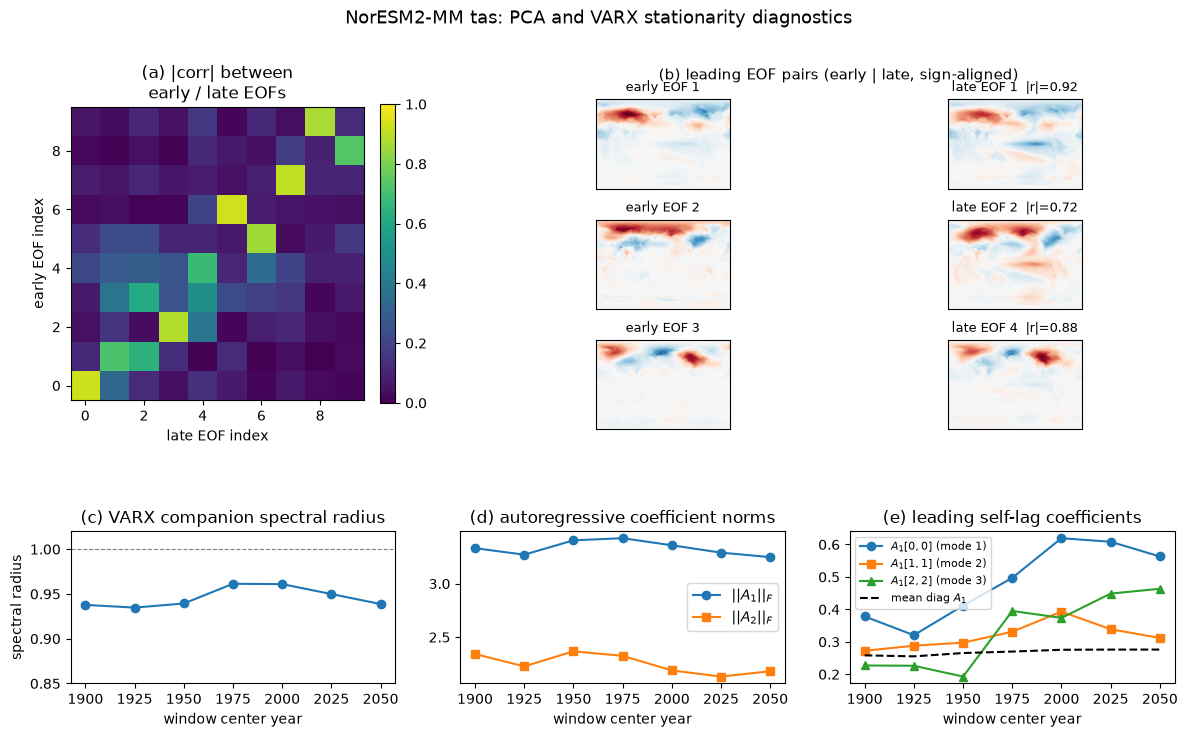

In [10]:
render_combined('tas', pca_tas, varx_tas, 'suppfig_stationarity_tas')

saved: ../paper/paper_figures/suppfig_stationarity_pr.pdf
saved: ../paper/paper_figures/suppfig_stationarity_pr.png


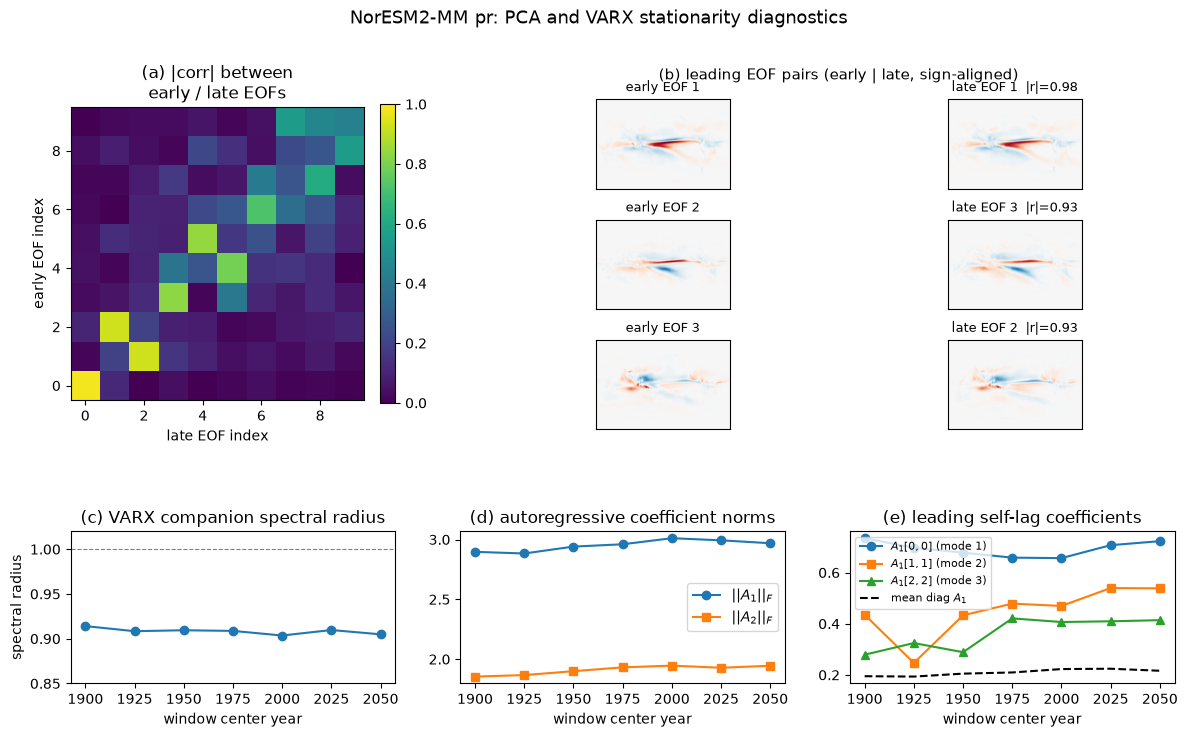

In [11]:
render_combined('pr', pca_pr, varx_pr, 'suppfig_stationarity_pr')

## 5. Numerical summary

For copying into the response letter.

In [12]:
def summarise(variable, pca_res, varx_res):
    print(f'--- {variable} ---')
    print(f'  PCA: leading pair |r|={pca_res["best"][0]:.3f}, top-10 best-match mean |r|={pca_res["best"].mean():.3f}')
    sr = [r['spectral_radius'] for r in varx_res['records']]
    a1 = [r['A1_frob'] for r in varx_res['records']]
    a2 = [r['A2_frob'] for r in varx_res['records']]
    dm = [r['A1_diag_mean'] for r in varx_res['records']]
    print(f'  VARX spectral radius: min={min(sr):.3f}, max={max(sr):.3f}')
    print(f'  VARX ||A1||_F: min={min(a1):.3f}, max={max(a1):.3f}  ({100*(max(a1)-min(a1))/np.mean(a1):.1f}% range)')
    print(f'  VARX ||A2||_F: min={min(a2):.3f}, max={max(a2):.3f}  ({100*(max(a2)-min(a2))/np.mean(a2):.1f}% range)')
    print(f'  VARX A1 diag mean: min={min(dm):.3f}, max={max(dm):.3f}')

summarise('tas', pca_tas, varx_tas)
summarise('pr', pca_pr, varx_pr)

--- tas ---
  PCA: leading pair |r|=0.924, top-10 best-match mean |r|=0.810
  VARX spectral radius: min=0.935, max=0.961
  VARX ||A1||_F: min=3.248, max=3.425  (5.3% range)
  VARX ||A2||_F: min=2.132, max=2.367  (10.5% range)
  VARX A1 diag mean: min=0.255, max=0.276
--- pr ---
  PCA: leading pair |r|=0.981, top-10 best-match mean |r|=0.774
  VARX spectral radius: min=0.904, max=0.914
  VARX ||A1||_F: min=2.883, max=3.011  (4.3% range)
  VARX ||A2||_F: min=1.855, max=1.946  (4.8% range)
  VARX A1 diag mean: min=0.193, max=0.224
